# Alzheimer's Disease detection

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# --- 1. Load and Preprocess Data (OASIS) ---
# Load the dataset
df = pd.read_csv('oasis_cross-sectional.csv')

# Drop rows with missing target variable (CDR) and critical features
df_clean = df.dropna(subset=['CDR', 'MMSE', 'Educ']).copy()

# Impute missing SES values with the median
median_ses = df_clean['SES'].median()
df_clean.loc[:, 'SES'] = df_clean['SES'].fillna(median_ses)

# Drop non-predictive/mostly empty columns
df_clean = df_clean.drop(['ID', 'Hand', 'Delay'], axis=1)

# Convert categorical 'M/F' to numerical (Male=1, Female=0)
df_clean.loc[:, 'M/F'] = df_clean['M/F'].apply(lambda x: 1 if x == 'M' else 0)

# Target Variable (y) and Feature Matrix (X)
# Map CDR values (0.0, 0.5, 1.0, 2.0) to class integers (0, 1, 2, 3)
cdr_mapping = {0.0: 0, 0.5: 1, 1.0: 2, 2.0: 3}
df_clean.loc[:, 'CDR_Class'] = df_clean['CDR'].map(cdr_mapping)

X = df_clean.drop(['CDR', 'CDR_Class'], axis=1)
y = df_clean['CDR_Class']
target_names = ['CDR 0.0 (Healthy)', 'CDR 0.5 (Very Mild)', 'CDR 1.0 (Mild)', 'CDR 2.0 (Moderate)']

# Split data (80% train, 20% test, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2. Tuned Gradient Boosting Model Training ---
# Best parameters found previously: learning_rate: 0.05, max_depth: 3, n_estimators: 200
best_gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=200,
    random_state=42
)

# Fit the model to the training data
best_gb_model.fit(X_train, y_train)

# --- 3. Evaluate and Predict ---
y_pred_tuned = best_gb_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print("\n--- Model Evaluation Results ---")
print(f"Tuned Gradient Boosting Test Accuracy: {accuracy_tuned:.4f}")

print("\nClassification Report:")
# The report uses the labels to ensure all four classes are shown
print(classification_report(y_test, y_pred_tuned, target_names=target_names, labels=[0, 1, 2, 3], zero_division=0))


--- Model Evaluation Results ---
Tuned Gradient Boosting Test Accuracy: 0.7021

Classification Report:
                     precision    recall  f1-score   support

  CDR 0.0 (Healthy)       0.77      0.89      0.83        27
CDR 0.5 (Very Mild)       0.57      0.57      0.57        14
     CDR 1.0 (Mild)       0.50      0.17      0.25         6
 CDR 2.0 (Moderate)       0.00      0.00      0.00         0

           accuracy                           0.70        47
          macro avg       0.46      0.41      0.41        47
       weighted avg       0.68      0.70      0.68        47



In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Data Preparation and Splitting ---
df = pd.read_csv('oasis_cross-sectional.csv')

# Preprocessing steps
df_clean = df.dropna(subset=['CDR', 'MMSE', 'Educ']).copy()
median_ses = df_clean['SES'].median()
df_clean.loc[:, 'SES'] = df_clean['SES'].fillna(median_ses)
df_clean = df_clean.drop(['ID', 'Hand', 'Delay'], axis=1)
df_clean.loc[:, 'M/F'] = df_clean['M/F'].apply(lambda x: 1 if x == 'M' else 0)

cdr_mapping = {0.0: 0, 0.5: 1, 1.0: 2, 2.0: 3}
df_clean.loc[:, 'CDR_Class'] = df_clean['CDR'].map(cdr_mapping)

X = df_clean.drop(['CDR', 'CDR_Class'], axis=1)
y = df_clean['CDR_Class']
target_names = ['CDR 0.0 (Healthy)', 'CDR 0.5 (Very Mild)', 'CDR 1.0 (Mild)', 'CDR 2.0 (Moderate)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling features (Crucial step)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. Train the Tuned Gradient Boosting Model ---
# Best parameters: learning_rate=0.05, max_depth=3, n_estimators=200
best_gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=200,
    random_state=42
)
best_gb_model.fit(X_train_scaled, y_train)

# Generate evaluation data
y_pred_gbc = best_gb_model.predict(X_test_scaled)
report_dict = classification_report(y_test, y_pred_gbc, target_names=target_names, labels=[0, 1, 2, 3], output_dict=True, zero_division=0)
conf_mat_gbc = confusion_matrix(y_test, y_pred_gbc)


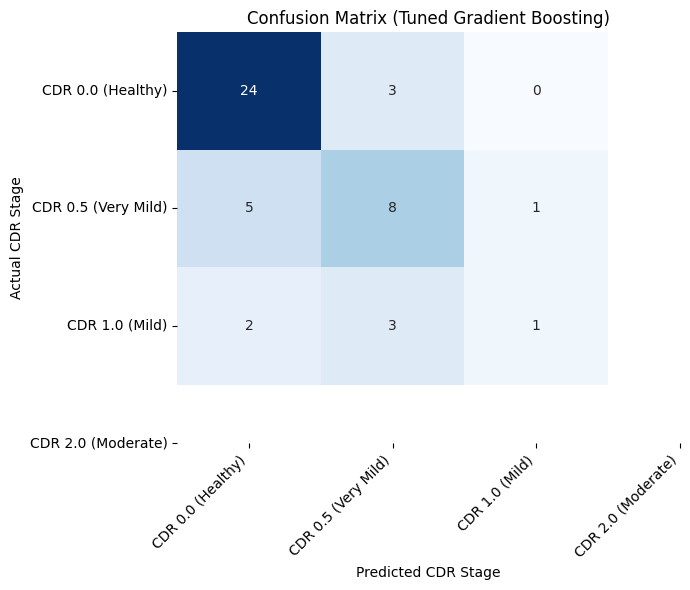

In [19]:
# --- 3. Graph Generation Code ---

# A. Confusion Matrix (gbc_confusion_matrix.png)
plt.figure(figsize=(7, 6))
sns.heatmap(conf_mat_gbc, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Tuned Gradient Boosting)')
plt.ylabel('Actual CDR Stage')
plt.xlabel('Predicted CDR Stage')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


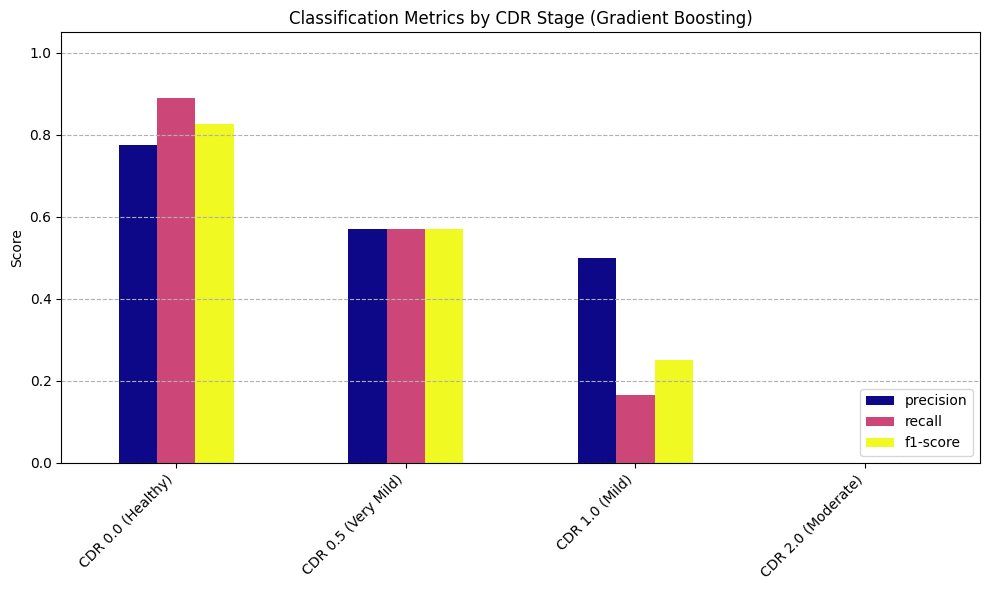

In [20]:
# B. Classification Metrics (gbc_metrics_barchart.png)
metrics_df = pd.DataFrame(report_dict).transpose()
plot_data = metrics_df.loc[target_names, ['precision', 'recall', 'f1-score']]
plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', ax=plt.gca(), colormap='plasma')
plt.title('Classification Metrics by CDR Stage (Gradient Boosting)')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

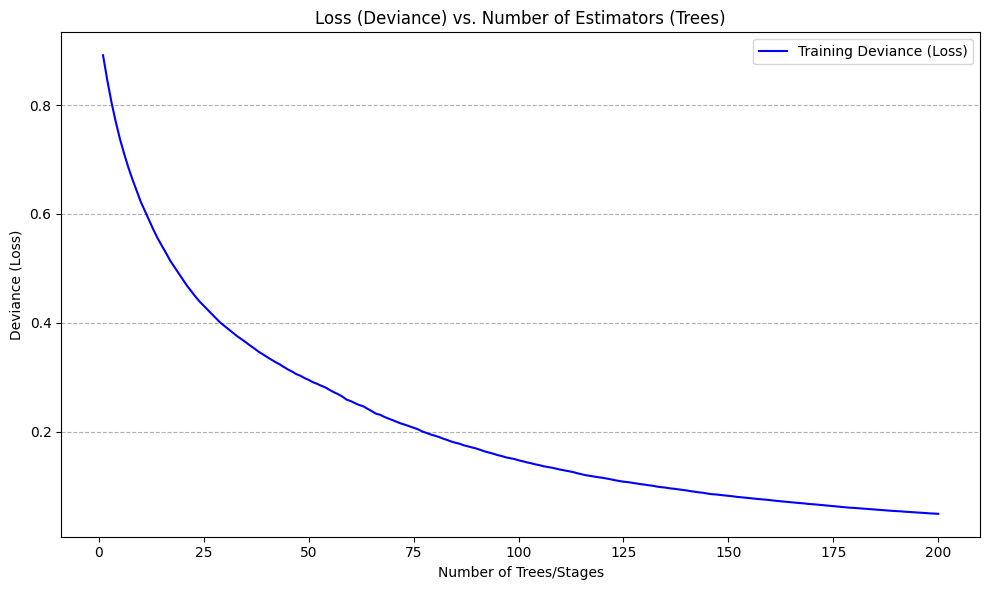

In [21]:
# C. Staged Loss Plot (gbc_staged_loss.png)
# Uses the training deviance (loss) tracked by the model at each tree addition
plt.figure(figsize=(10, 6))
plt.plot(np.arange(best_gb_model.n_estimators) + 1, best_gb_model.train_score_, label='Training Deviance (Loss)', color='blue')
plt.title('Loss (Deviance) vs. Number of Estimators (Trees)')
plt.xlabel('Number of Trees/Stages')
plt.ylabel('Deviance (Loss)')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

0, 75, 3, 3, 25, 1400, 0.75, 1.2


ValueError: invalid literal for int() with base 10: '0, 75, 3, 3, 25, 1400, 0.75, 1.2'

In [29]:
# Assuming you have the trained model (best_gb_model) and the scaler object (scaler)
# from the previous steps.

# Define the CORRECT column order based on the training data (X)
CORRECT_FEATURE_ORDER = ['M/F', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']

# Example new data for a 75-year-old female:
# M/F: 0 (Female), Age: 75, Educ: 3, SES: 3, MMSE: 25, eTIV: 1400, nWBV: 0.75, ASF: 1.2
new_patient_data = np.array([[0, 75, 3, 3, 25, 1400, 0.75, 1.2]])

# Create the DataFrame using the CORRECT order
new_patient_df = pd.DataFrame(
    new_patient_data,
    columns=CORRECT_FEATURE_ORDER
)

# 1. Scale the new data (This will now work)
new_patient_scaled = scaler.transform(new_patient_df)

# 2. Make the prediction (returns an integer class 0, 1, 2, or 3)
prediction_class = best_gb_model.predict(new_patient_scaled)[0]

# 3. Map the integer prediction back to the CDR score
cdr_scores = {0: 'CDR 0.0 (Healthy)', 1: 'CDR 0.5 (Very Mild)', 2: 'CDR 1.0 (Mild)', 3: 'CDR 2.0 (Moderate)'}
predicted_cdr = cdr_scores[prediction_class]

print(f"Predicted CDR Class: {predicted_cdr}")

Predicted CDR Class: CDR 0.5 (Very Mild)
